# 📖 RAG Tutorial: Building a Question-Answering System for a Theater Play

## 🎭 Use-Case Introduction

In this tutorial, we will explore **Retrieval-Augmented Generation (RAG)**, a technique that enhances language models by integrating an external knowledge retrieval component. Instead of relying solely on a massive pretrained model, we will demonstrate that **a well-designed RAG system, coupled with a relatively small model (less than 10B parameters), can effectively answer questions about a given text**.

To make this tutorial engaging and concrete, we will work with **_L'Avare_ ("The Miser")**, a famous French play written by **Molière**. This classic 17th-century comedy revolves around the character **Harpagon**, a miserly old man obsessed with wealth, leading to humorous conflicts with his children and servants.

### 📚 Data Source

We will use a **public domain version of _The Miser_ from [Project Gutenberg](https://www.gutenberg.org/)**, a digital library that provides free access to literary works. This text will serve as the **knowledge base** for our retrieval system.

By the end of this tutorial, you will learn how to:
- Retrieve relevant passages from a document to answer user queries.
- Use a **retrieval-augmented generation (RAG) system** instead of relying on a purely generative approach.
- Evaluate the effectiveness of different retrieval strategies.

🚀 **Let's get started!**


<div class="alert alert-warning">
Go on Google Colab for this notebook. Better if you can have a T4 Runtime GPU!
</div>

In [1]:
!pip install -q transformers accelerate torch sentence-transformers

In [ ]:
!pip install -q langchain_core langchain_community langchain_huggingface langchain_mistralai langchain_google_genai langchain_experimental langchain_qdrant fastembed-gpu

## 📥 Loading and Cleaning the Play

We begin by loading the text of The Miser from Project Gutenberg and performing some basic cleaning. Since Gutenberg texts contain metadata (licensing information, disclaimers, etc.), we will extract only the play's content.

**Load the play**

<div class="alert alert-warning">
Don't forget to actually upload the play in your Colab workspace and the csv file that I sent you!
</div>

In [4]:
from langchain_community.document_loaders import TextLoader

# Load the text file from disk
loader = TextLoader('toy_data/the_miser_moliere.txt')

# Extract the text content into a list of Document objects
text = loader.load()

**Clean the text**

In [5]:
import re

def extract_from_gutenberg_text(full_txt: str) -> str:
    """
    Extracts the actual play content by removing Project Gutenberg's metadata.
    The function identifies start and end markers that delimit the play.

    Args:
        full_txt (str): Raw text loaded from the file.

    Returns:
        str: Cleaned text containing only the play's content.
    """
    start_marker = r"START OF THE PROJECT GUTENBERG EBOOK THE MISER \*\*\*\n\n\n\n\n"
    end_marker = r"\n\n\n\n\n\*\*\* END OF THE PROJECT GUTENBERG EBOOK THE MISER"

    match = re.search(f"{start_marker}(.*?){end_marker}", full_txt, re.DOTALL)

    if match:
        return match.group(1).strip()
    else:
        raise ValueError("Markers not found in the text! Ensure you have the correct file format.")

def remove_singleline_breaks(text: str) -> str:
    """
    Cleans up the text by removing unnecessary single-line breaks
    while preserving paragraph breaks.

    Args:
        text (str): Input text with inconsistent line breaks.

    Returns:
        str: Processed text with standardized paragraph formatting.
    """
    text = re.sub(r"(?<!\n)\n(?!\n)", " ", text)  # Merge single line breaks into one continuous line
    return text.strip()


In [6]:
# Extract raw text content
raw_text = text[0].page_content

# Clean the text
clean_text = extract_from_gutenberg_text(raw_text)
clean_text = remove_singleline_breaks(clean_text)

# Replace the document content with the cleaned version
text[0].page_content = clean_text

# Display the first 50 characters
text[0].page_content[:50]

"THE MISER. (L'AVARE.)\n\nby\n\nMOLIÈRE\n\nTranslated int"

## 📑 Splitting the Text into Chunks

Next, we split the text into smaller retrievable chunks. A key part of RAG is efficient retrieval, and this requires well-structured chunking.

**Chunking the text**

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Define a hierarchical text splitter
text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],  # Prioritize keeping paragraphs together, then sentences, then words.
    chunk_size=256,  # Aim for chunks of around 256 characters
    chunk_overlap=16,  # Overlap chunks by 16 characters to preserve context
)

# Apply the splitter
docs_v0 = text_splitter.split_documents(text)

At this stage, we have successfully **loaded, cleaned, and chunked** our text, making it ready for retrieval. This process is known as **Data Ingestion**, a crucial step in building effective RAG systems.

### 🔹 What is Data Ingestion?
Data Ingestion refers to the process of **loading, cleaning, structuring, and storing** data so that it can be efficiently retrieved later. Every step involved **choices** that impact retrieval quality.

Later in this tutorial, we will explore **alternative ingestion strategies** and evaluate their impact on retrieval performance.

## 📊 Define a Small Evaluation Set for Qualitative Analysis

Before testing our RAG system, we need a small set of sample queries along with their expected answers and reference contexts. This will allow us to eyeball (qualitatively assess) how well our system retrieves and generates responses.

In [8]:
import pandas as pd

# 🔍 Sample Queries for Evaluating RAG Performance
# This small set helps us quickly assess retrieval quality.
# Feel free to extend this list for more thorough testing.
sample_queries = [
    "In which city is the play 'The Miser' happening?",
    "Who are the characters involved in 'The Miser' play?",
    "Who is Elise's lover in 'The Miser'?",
    "Who is Mistress Claude for Harpagon in 'The Miser'?"
]

# 🎯 Expected Responses (Ground Truth)
expected_responses = [
    "Paris",
    "Harpagon, Cléante, Valère, Anselme, Master Simon, Master Jacques, La Flèche, Brindavoine, La Merluche, A Magistrate and his clerk, Elise, Marianne, Frosine and Mistress Claude",
    "Elise's lover is Valère, son of Anselme",
    "Mistress Claude is Harpagon's servant"
]

# 📖 Reference Contexts (Where the Answer is Found in the Play)
reference_contexts = [
    ["The scene is at Paris, in Harpagon's house."],
    [
        """
        PERSONS REPRESENTED.

        HARPAGON, _father to_ CLÉANTE, _in love with_ MARIANNE.
        CLÉANTE, HARPAGON'S _son, lover to_ MARIANNE.
        VALÈRE, _son to_ ANSELME, _and lover to_ ÉLISE.
        ANSELME, _father to_ VALÈRE _and_ MARIANNE.
        MASTER SIMON, _broker_.
        MASTER JACQUES, _cook and coachman to_ HARPAGON.
        LA FLÈCHE, _valet to_ CLÉANTE.
        BRINDAVOINE _and_ LA MERLUCHE, _lackeys to_ HARPAGON.
        A MAGISTRATE _and his_ CLERK.
        ÉLISE, _daughter to_ HARPAGON.
        MARIANNE, _daughter to_ ANSELME.
        FROSINE, _an intriguing woman_.
        MISTRESS CLAUDE, _servant to_ HARPAGON.
        """
    ],
    ["VALÈRE, _son to_ ANSELME, _and lover to_ ÉLISE."],
    ["MISTRESS CLAUDE, _servant to_ HARPAGON."]
]

# 📊 Create a DataFrame for Easy Comparison
qualitative_dataset = pd.DataFrame(
    {
        "user_input": sample_queries,
        "reference_contexts": reference_contexts,
        "reference": expected_responses
    }
)

# Display the dataset
qualitative_dataset.head()

,user_input,reference_contexts,reference
0,In which city is the play 'The Miser' happening?,"[The scene is at Paris, in Harpagon's house.]",Paris
1,Who are the characters involved in 'The Miser'...,[\n PERSONS REPRESENTED.\n\n HAR...,"Harpagon, Cléante, Valère, Anselme, Master Sim..."
2,Who is Elise's lover in 'The Miser'?,"[VALÈRE, _son to_ ANSELME, _and lover to_ ÉLISE.]","Elise's lover is Valère, son of Anselme"
3,Who is Mistress Claude for Harpagon in 'The Mi...,"[MISTRESS CLAUDE, _servant to_ HARPAGON.]",Mistress Claude is Harpagon's servant


### 🔹 Why This Step Matters?
This dataset can help us:

- Quickly assess retrieval effectiveness by comparing retrieved vs. expected contexts.
- Spot potential issues in chunking or retrieval (e.g., missing key information).
- Validate response coherence before running full-scale evaluation.

Later, we will load a larger dataset to run evaluation metrics, but this provides a solid starting point. (especially for eye-balling results)

## 🛠 First Examples & RAG Interface

Now that we have prepared our dataset, it's time to build our **first RAG system**!  

## 🔹 Why Use LangChain & Various APIs?
To simplify working with **language models** and **retrieval-based augmentation**, we use:
- **[LangChain](https://python.langchain.com/)**: A powerful framework for LLM-based applications, including retrieval and generation.
- **MistralAI, Google Generative AI**: To leverage different language models for generation and embeddings without having to handle the hardware burden of using such large models.

We'll first define:
- A **generation model** (`ChatMistralAI`) for answering questions.
- An **embedding model** (`HuggingFaceEmbeddings`) for later retrieval.

Next, we will create a **RAG Interface** to standardize retrieval and generation.


If you did not, you first need to create a Mistral API key from [here](https://console.mistral.ai/home). Then, you should add it in the Colab Workspace (the logo with the Key on the left-side bar).
You should also create an API key from your HuggingFace and also add it in the workspace.

In [9]:
from google.colab import userdata
from langchain_mistralai import ChatMistralAI

generation_llm = ChatMistralAI(
    model="ministral-3b-2512",
    api_key=userdata.get("mistral_api"), # if on Colab and Secret is named that way
    temperature=0,
    max_retries=2,
    # other params...
)

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize an embedding model for vector-based retrieval (used later)
# It is a common sentence transformer model for embeddings
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 🔹 Defining a RAG Interface

To ensure **modularity and flexibility**, we define a **RAGInterface** using Python’s `ABC` (Abstract Base Class). This will allow us to later swap different retrieval strategies while maintaining a consistent API.

**Key Components of the RAG Interface:**
- `retrieve(query)`: Retrieves relevant contexts based on the input query.
- `generate(query, retrieved_contexts)`: Generates an answer using both the query and retrieved documents.

We take inspiration from LangChain’s [official RAG tutorial](https://python.langchain.com/docs/tutorials/rag/).

In [11]:
from abc import abstractmethod, ABC
from langchain_core.documents import Document
from typing import List, Optional, Any, Union

class RAGInterface(ABC):
    """
    Abstract class defining a generic RAG system.

    This class ensures that all RAG implementations follow a common structure.
    """

    def __init__(self, name: str, knowledge_db: Optional[Any] = None):
        self.name = name  # Identifier for the RAG system
        self.knowledge_db = knowledge_db  # Storage backend (e.g., a vector database)

    @abstractmethod
    def retrieve(self, query: str) -> List[Document]:
        """
        Retrieve relevant contexts from the knowledge_db based on the query.

        Args:
            query (str): The user query.

        Returns:
            List[Document]: Retrieved document chunks.
        """
        pass

    @abstractmethod
    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        """
        Generate a response based on the query and retrieved contexts.

        Args:
            query (str): The user query.
            retrieved_contexts (List[Document]): Relevant document chunks.

        Returns:
            str: The generated response.
        """
        pass

### 🔹 Running a RAG Model on a DataFrame

To later **evaluate** a given RAG implementation, we define a helper function `run_rag_on_df()` that:
1. **Retrieves** relevant contexts for each query.
2. **Generates** an answer using the retrieved documents.
3. **Stores** the retrieved contexts and responses in a new DataFrame.

In [12]:
def run_rag_on_df(rag: RAGInterface, eval_df: pd.DataFrame) -> pd.DataFrame:
    """
    Runs a RAG system on a dataset and store responses.

    Args:
        rag (RAGInterface): The RAG system to evaluate.
        eval_df (pd.DataFrame): DataFrame containing user queries and references.

    Returns:
        pd.DataFrame: The updated DataFrame including retrieved contexts and generated responses.
    """
    rag_df = eval_df.copy()

    # Retrieve relevant contexts for each query
    rag_df["retrieved_contexts"] = rag_df["user_input"].apply(rag.retrieve)

    # Generate answers using the retrieved contexts
    rag_df["response"] = rag_df.apply(
        lambda row: rag.generate(row["user_input"], row["retrieved_contexts"]), axis=1
    )

    # Convert retrieved documents to their text content
    rag_df["retrieved_contexts"] = rag_df["retrieved_contexts"].apply(
        lambda rcontexts: [rcontext.page_content for rcontext in rcontexts]
    )

    # Track the RAG implementation used
    rag_df["rag_name"] = rag.name

    return rag_df


### 🔹 Baseline: A Non-RAG Model (Just Generation)

To compare performance, we define a **"NotARAG"** model that:
- **Does not retrieve any documents** (simulating a naive LLM-based approach).
- Generates responses purely based on the **query**.

This allows us to later compare retrieval-augmented models against **pure generation**.


In [13]:
from langchain_huggingface import ChatHuggingFace

In [14]:
def get_model_name(generation_model: Union[ChatMistralAI, ChatHuggingFace]):
    """
    Util to get a model name once wrapped with Langchain
    """
    if isinstance(generation_model, ChatHuggingFace):
        return generation_model.model_id
    return generation_model.model

In [15]:
class NotARAG(RAGInterface):
    """
    Baseline model that does not use retrieval (pure generation).

    This is useful as a comparison point for evaluating RAG performance.
    """

    def __init__(self, generation_model: Union[ChatMistralAI, ChatHuggingFace]):
        model_name = get_model_name(generation_model)
        name = f"not_a_rag_{model_name}"
        super().__init__(name=name)
        self.llm = generation_model  # Language model for generation

    def retrieve(self, query: str) -> List[Document]:
        """
        Since this is NOT a RAG system, we return an empty document.
        This ensures consistency with RAG-based evaluations.
        """
        retrieved_contexts = [Document(page_content="", metadata={})]
        return retrieved_contexts

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        """
        Generates a response using only the query (ignoring retrieved contexts).
        """
        response = self.llm.invoke(query)
        return response

### 🔹 Running Our Baseline Model

Now, we run our **NotARAG** model on our predefined dataset.
This allows us to **compare retrieval-augmented models against pure generation**.

In [16]:
# Initialize a baseline model (no retrieval)
mistral_base = NotARAG(generation_model=generation_llm)

# Run the model on our qualitative dataset
mistral_base_qualitative_df = run_rag_on_df(rag=mistral_base, eval_df=qualitative_dataset)

### 🔹 Displaying RAG Results in Markdown

To make it easier to **visually compare** responses, we define a helper function:
- Uses **Markdown formatting** for better readability in Jupyter Notebooks.
- Clearly distinguishes between **User Query, Reference Answer, RAG Answer, Reference Contexts, and Retrieved Contexts**.

In [17]:
from IPython.display import Markdown

def print_markdown(text):
    """Helper function to display text as Markdown."""
    display(Markdown(text))

def pp_qualitative_results(qualitative_df: pd.DataFrame, sample_index: int = 0):
    """
    Pretty prints a RAG response and its retrieved contexts.

    Args:
        qualitative_df (pd.DataFrame): DataFrame with qualitative results.
        sample_index (int): Index of the sample to display.
    """
    sample_row = qualitative_df.iloc[sample_index]

    print_markdown(f"### RAG: {sample_row['rag_name']} - Sample #{sample_index}")
    print_markdown("**User Query:**")
    print_markdown(f"{sample_row['user_input']}")
    print_markdown("**Reference Answer:**")
    print_markdown(f"{sample_row['reference']}")
    print_markdown("**RAG Answer:**")
    print_markdown(f"{sample_row['response']}")
    print_markdown("---------\n")
    print_markdown("**Reference Contexts:**")
    for i, rc in enumerate(sample_row['reference_contexts']):
        print_markdown(f"- Context {i}: {rc}")
    print_markdown("---------\n")
    print_markdown("**Retrieved Contexts:**")
    for i, rc in enumerate(sample_row['retrieved_contexts']):
        print_markdown(f"- Context {i}: {rc}")


Let's inspect the first sample. (Feel free to change the value of `sample_index` to see the other samples.

In [18]:
pp_qualitative_results(qualitative_df=mistral_base_qualitative_df, sample_index=1)

### RAG: not_a_rag_ministral-3b-2512 - Sample #1

**User Query:**

Who are the characters involved in 'The Miser' play?

**Reference Answer:**

Harpagon, Cléante, Valère, Anselme, Master Simon, Master Jacques, La Flèche, Brindavoine, La Merluche, A Magistrate and his clerk, Elise, Marianne, Frosine and Mistress Claude

...

**Reference Contexts:**

- Context 0: 
        PERSONS REPRESENTED.

        HARPAGON, _father to_ CLÉANTE, _in love with_ MARIANNE.
        CLÉANTE, HARPAGON'S _son, lover to_ MARIANNE.
        VALÈRE, _son to_ ANSELME, _and lover to_ ÉLISE.
        ANSELME, _father to_ VALÈRE _and_ MARIANNE.
        MASTER SIMON, _broker_.
        MASTER JACQUES, _cook and coachman to_ HARPAGON.
        LA FLÈCHE, _valet to_ CLÉANTE.
        BRINDAVOINE _and_ LA MERLUCHE, _lackeys to_ HARPAGON.
        A MAGISTRATE _and his_ CLERK.
        ÉLISE, _daughter to_ HARPAGON.
        MARIANNE, _daughter to_ ANSELME.
        FROSINE, _an intriguing woman_.
        MISTRESS CLAUDE, _servant to_ HARPAGON.
        

---------


**Retrieved Contexts:**

- Context 0: 

In [19]:
pp_qualitative_results(qualitative_df=mistral_base_qualitative_df, sample_index=2)

### RAG: not_a_rag_ministral-3b-2512 - Sample #2

**User Query:**

Who is Elise's lover in 'The Miser'?

**Reference Answer:**

Elise's lover is Valère, son of Anselme

...

**Reference Contexts:**

- Context 0: VALÈRE, _son to_ ANSELME, _and lover to_ ÉLISE.

---------


**Retrieved Contexts:**

- Context 0: 

<div class='alert alert-warning'>
    ⚠️ Even though I can't predict exactly what your model will answer, you will likely observe some hallucinations...
</div>

It's a bit frustrating, right? **Mistral**, despite being a capable model, struggles with answering questions about such a well-known classic.  

Even worse, using a **larger model** just to answer simple questions about a theater play seems unnecessary and inefficient.

**This is exactly why we need Retrieval-Augmented Generation (RAG)!**  
Instead of relying solely on a generative model's **parametric knowledge**, we can equip it with **retrieval capabilities**, allowing it to pull information directly from a relevant knowledge base.

### 🗄️ **Indexing, Stores, and Qdrant**
To make retrieval efficient, we need to **store and search through our knowledge base** effectively. This involves:

#### 🔍 **Indexing**
Before retrieval, we must **index** our text chunks by converting them into searchable representations.  
There are two primary approaches:
1. **Sparse Retrieval (BM25, TF-IDF, etc.)** → Works well for **keyword-based search**.
2. **Dense Retrieval (Embeddings, Vector Search)** → Works well for **semantic similarity**.

#### 🏛️ **Vector Stores**
A **vector store** allows us to **store and search embeddings efficiently**.  
Many vector databases support **dense retrieval**, but for true **hybrid search**, we need one that can handle **both dense and sparse embeddings**.

#### 🚀 **Why Qdrant?**
In this tutorial, we will use **[Qdrant](https://python.langchain.com/docs/integrations/vectorstores/qdrant)** because:
- ✅ It supports **hybrid search**, combining **BM25 (sparse) and embeddings (dense)**.
- ✅ It is **optimized for high-performance retrieval**.
- ✅ It can leverage metadatas.
- ✅ It works well with LangChain.

## 🏗️ Build Our First RAG Using Sparse Retrieval (BM25)

Now, we will build our **first RAG system** using **BM25-based sparse retrieval**.

### 📌 Why BM25?  
BM25 (Best Matching 25) ["is a ranking function used by search engines to estimate the relevance of documents to a given search query."](https://en.wikipedia.org/wiki/Okapi_BM25). It works well when:
- **Exact keyword matching** is important.
- We want a **lightweight, interpretable retrieval method**.

While **BM25 does not capture semantic meaning**, it is often **surprisingly effective**—especially for structured texts like **plays, books, or legal documents**. It is a good practice to make a first pipeline that uses this method!


In [20]:
from langchain_core.prompts import PromptTemplate
from langchain_qdrant import QdrantVectorStore, FastEmbedSparse, RetrievalMode

# 📝 Define a Structured Prompt for Generation
prompt_template_v0 = """
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.
Question: {query}
Context: {retrieved_contexts}
Answer:
"""

# Create a prompt template from the string
gen_prompt_v0 = PromptTemplate.from_template(prompt_template_v0)

# 🔎 Define BM25-Based RAG System
class BM25V0RAG(RAGInterface):
    """
    Sparse Retrieval RAG using BM25 and Qdrant.

    - Stores text chunks in Qdrant using BM25 sparse embeddings.
    - Retrieves the top-k relevant chunks based on keyword matching.
    - Uses a language model to generate answers from retrieved contexts.
    """

    def __init__(self, generation_model: ChatHuggingFace):
        # Initialize BM25 sparse embeddings
        sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

        # Store documents in Qdrant using sparse retrieval
        knowledge_db = QdrantVectorStore.from_documents(
            docs_v0,  # Pre-processed text chunks
            embedding=embedding,  # Not used in this mode, but required
            sparse_embedding=sparse_embeddings,  # BM25 embeddings
            location=":memory:",  # Store in-memory (can be changed to persistent storage)
            collection_name="the_miser_sparse_v0",
            retrieval_mode=RetrievalMode.SPARSE,  # Use only sparse retrieval
        )

        # Define model name dynamically
        model_name = get_model_name(generation_model)
        name = f"bm25_v0_{model_name}"
        super().__init__(name=name, knowledge_db=knowledge_db)

        # Initialize the LLM and retriever
        self.llm = generation_model
        self.retriever = self.knowledge_db.as_retriever(
            search_type="similarity", search_kwargs={"k": 5}  # Retrieve top 5 matches
        )
        self.gen_prompt = gen_prompt_v0  # Use the structured prompt

    def retrieve(self, query: str) -> List[Document]:
        """
        Retrieves relevant documents using BM25 sparse retrieval.

        Args:
            query (str): The user query.

        Returns:
            List[Document]: The most relevant document chunks.
        """
        retrieved_contexts = self.retriever.invoke(query)
        return retrieved_contexts

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        """
        Generates a response using the retrieved contexts.

        Args:
            query (str): The user query.
            retrieved_contexts (List[Document]): Retrieved document chunks.

        Returns:
            str: The generated answer.
        """
        # Format retrieved contexts into a single string
        format_retrieved_contexts = "\n".join([rc.page_content for rc in retrieved_contexts])

        # Format the query with the retrieved contexts
        augmented_query = self.gen_prompt.format(
            query=query,
            retrieved_contexts=format_retrieved_contexts
        )

        # Generate the final response
        response = self.llm.invoke(augmented_query)
        return response

**Running Our First BM25-Based RAG**

In [21]:
# Initialize BM25 RAG system
bm25_v0 = BM25V0RAG(generation_model=generation_llm)

# Run the evaluation using our predefined dataset
bm25_v0_qualitative_df = run_rag_on_df(rag=bm25_v0, eval_df=qualitative_dataset)

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

dutch.txt:   0%|          | 0.00/453 [00:00<?, ?B/s]

french.txt:   0%|          | 0.00/813 [00:00<?, ?B/s]

arabic.txt: 0.00B [00:00, ?B/s]

english.txt:   0%|          | 0.00/936 [00:00<?, ?B/s]

...

norwegian.txt:   0%|          | 0.00/851 [00:00<?, ?B/s]

hungarian.txt: 0.00B [00:00, ?B/s]

spanish.txt: 0.00B [00:00, ?B/s]

swedish.txt:   0%|          | 0.00/559 [00:00<?, ?B/s]

turkish.txt:   0%|          | 0.00/260 [00:00<?, ?B/s]

**Inspecting BM25-Based RAG Results**

Let's check how well our **BM25-based retrieval** performs by looking at a sample response.

Try different `sample_index` values to compare results on multiple queries.

In [22]:
pp_qualitative_results(qualitative_df=bm25_v0_qualitative_df, sample_index=3)

### RAG: bm25_v0_ministral-3b-2512 - Sample #3

**User Query:**

Who is Mistress Claude for Harpagon in 'The Miser'?

**Reference Answer:**

Mistress Claude is Harpagon's servant

...

- Context 0: and coachman to_ HARPAGON. LA FLÈCHE, _valet to_ CLÉANTE. BRINDAVOINE _and_ LA MERLUCHE, _lackeys to_ HARPAGON. A MAGISTRATE _and his_ CLERK. ÉLISE, _daughter to_ HARPAGON. MARIANNE, _daughter to_ ANSELME. FROSINE, _an intriguing woman_. MISTRESS CLAUDE,

- Context 1: CLAUDE, _servant to_ HARPAGON.

- Context 2: *       *       *       *       *

_The scene is at_ PARIS, _in_ HARPAGON'S _house_.




THE MISER.



ACT I.

SCENE I.--VALÈRE, ÉLISE.

- Context 3: ACT III.

SCENE I.--HARPAGON, CLÉANTE, ÉLISE, VALÈRE, DAME CLAUDE (_holding a broom_), MASTER JACQUES, LA MERLUCHE, BRINDAVOINE.

- Context 4: JAC. (_aside_). A shrewd punishment that.

HAR. (_to_ DAME CLAUDE.) Now you may go.


SCENE II.--HARPAGON, CLÉANTE, ÉLISE, VALÈRE, MASTER JACQUES, BRINDAVOINE, LA MERLUCHE.

## 📈 Setting Up an Evaluation Pipeline for RAG

Before experimenting with different RAG strategies, it is essential to **set up a proper evaluation pipeline**.  

🔹 **Why?**  
An evaluation pipeline ensures that we can **consistently measure performance** across different RAG implementations. Without it, we risk making subjective or anecdotal judgments.  

### **How Do We Evaluate RAG?**  
Evaluating RAG systems involves assessing **both retrieval quality and answer generation**. We use **four key metrics** to measure different aspects of performance:

1️⃣ **Correctness** → Does the model generate a factually accurate answer?  
2️⃣ **Relevance** → Does the response directly address the question?  
3️⃣ **Groundedness** → Is the response grounded in the retrieved documents (i.e., no hallucination)?  
4️⃣ **Retrieval Relevance** → Are the retrieved documents actually useful for answering the question?  

However, evaluating RAG is **not straightforward** because these metrics often involve **subjective judgment** rather than simple right/wrong answers.  
Thus, we need a reliable evaluator to assess these aspects.  

Since **human evaluation is expensive** (and we are still in a prototyping phase), we will instead rely on... **LLMs to evaluate our RAG!**  

### **LLM-Based Evaluation: Why Use a Language Model to Evaluate Another?**
Instead of relying on **manual human annotation**, we leverage **LLM Evaluators**, which:  
✅ Act as **automatic graders**, providing **scalable and consistent** evaluation.  
✅ Reduce the need for **expensive human review**.  
✅ Can **explain their reasoning**, improving interpretability.  

While **LLM-based grading isn't perfect**, it allows us to efficiently benchmark RAG models in an **automated, cost-effective way**.  

💡 **Note:** While not mandatory, it is often beneficial to use a **more powerful model** for evaluation to ensure more reliable assessments!

### Using Gemini as the Evaluator

We will use a Gemini model via API calls to play the role of the evaluator. (I gave you an API key at the beginning of the class, don't forget to add it to your Colab workspace).



### 🗂️ Loading an Evaluation Dataset

In [23]:
NB_OF_SAMPLES = 20  # Small number for demonstration, but should be larger in real evaluations

# Load a dataset of question-answer-context (QAC) pairs
eval_df = pd.read_csv('toy_data/the_miser_qac.csv', sep=';', index_col=0)

# Reset index for consistency
eval_df.reset_index(drop=True, inplace=True)

# Remove unnecessary columns
eval_df.drop(columns="synthesizer_name", inplace=True)

# Sample a subset for evaluation
eval_df = eval_df.sample(n=NB_OF_SAMPLES, random_state=42)

💡 **Note:** The evaluation dataset was **also generated by an LLM**. This means:
- The **ground truth answers** were synthesized rather than being manually written.
- The dataset may contain **biases from the model that created it**.
- Using **a different model for evaluation** helps mitigate self-reinforcement issues.


<div class="alert alert-warning">
Do not hesitate to dive into this evaluation dataset and to be critic about it!
</div>

**Running BM25 RAG on the Evaluation Dataset**

We now run our **BM25-based RAG system** on the evaluation dataset to collect generated responses.

In [24]:
bm25_v0_df = run_rag_on_df(rag=bm25_v0, eval_df=eval_df)

# Display a few rows
bm25_v0_df.head(5)

,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[CLE. What?\n\nLA FL. I have watched for this ...,"content='The mysterious figure is **a shadowy,...",bm25_v0_ministral-3b-2512
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...","[ELI. Yes, whatever he thinks right, I will do...","content='According to the context, **Valère is...",bm25_v0_ministral-3b-2512
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[FRO. What have I come to do? Why! what I do e...,content='Fro’s warning is that he **should not...,bm25_v0_ministral-3b-2512
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[CLE. To me?\n\nHAR. To you.\n\nCLE. In marria...,content='Har suggests that Valère should act a...,bm25_v0_ministral-3b-2512
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,"[HAR. I want to give her to-night, for a husba...",content='Har tells Eli that he will force him ...,bm25_v0_ministral-3b-2512


### 🏆 Implementing an LLM-Based Evaluation Framework

Since **manual evaluation is impractical at scale**, we use an **LLM evaluator** to automate scoring.  

We define a **BaseLLMEvaluator** class that:
- Uses **ChatGoogleGenerativeAI** (running **Gemini 2.5 Flash Lite**) for grading.
- Applies structured output formatting.
- Serves as an interface for every metric

In [25]:
from langchain_google_genai import ChatGoogleGenerativeAI

gemini_model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    api_key=userdata.get('isae_gem'),
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [26]:
from typing import Union
from typing_extensions import Annotated, TypedDict
from tqdm.auto import tqdm

class BaseLLMEvaluator(ABC):
    """
    Base class for LLM-based evaluation of RAG-generated responses.

    - Uses an LLM to grade responses based on predefined criteria.
    - Supports structured output and automatic batch processing.
    """

    def __init__(self, llm_eval_name: str, metric_name: str, output_schema: TypedDict, system_prompt: str):
        self.llm_eval_name = llm_eval_name
        self.metric_name = metric_name
        self.system_prompt = system_prompt
        self.llm = gemini_model.with_structured_output(output_schema, method="json_schema")

    @abstractmethod
    def evaluate(self, row) -> Union[bool, float]:
        """Abstract method for evaluating a single row."""
        pass

    def apply_to_dataframe(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Applies the metric to all rows in a DataFrame with a progress bar.

        Args:
            df (pd.DataFrame): DataFrame containing RAG results.

        Returns:
            pd.DataFrame: Updated DataFrame with evaluation scores.
        """
        tqdm.pandas(desc=f"Evaluating {self.metric_name}")
        df[self.metric_name] = df.progress_apply(self.evaluate, axis=1)
        return df

#### ✅ Metric #1: Correctness (Is the answer factually accurate?)

In [27]:
# Grade output schema
class CorrectnessGrade(TypedDict):
    # Note that the order in the fields are defined is the order in which the model will generate them.
    # It is useful to put explanations before responses because it forces the model to think through
    # its final response before generating it:
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise."]

# Grade prompt
CORRECTNESS_INSTRUCTIONS = """You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer.
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the  ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset."""

class Correctness(BaseLLMEvaluator):
    def __init__(self, llm_eval_name: str = "gemini-2.5-flash-lite"):
        super().__init__(
            llm_eval_name = llm_eval_name,
            metric_name = "correctness",
            output_schema = CorrectnessGrade,
            system_prompt = CORRECTNESS_INSTRUCTIONS
        )
    def evaluate(self, row) -> bool:
        user_prompt = f"""      QUESTION: {row["user_input"]}
    GROUND TRUTH ANSWER: {row["reference"]}
    STUDENT ANSWER: {row["response"]}"""
        # Run evaluator
        grade = self.llm.invoke([{"role": "system", "content": self.system_prompt}, {"role": "user", "content": user_prompt}])
        return grade["correct"]

In [28]:
correctness = Correctness()
correctness.apply_to_dataframe(bm25_v0_df)
bm25_v0_df.head(5)

Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name,correctness
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[CLE. What?\n\nLA FL. I have watched for this ...,"content='The mysterious figure is **a shadowy,...",bm25_v0_ministral-3b-2512,True
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...","[ELI. Yes, whatever he thinks right, I will do...","content='According to the context, **Valère is...",bm25_v0_ministral-3b-2512,True
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[FRO. What have I come to do? Why! what I do e...,content='Fro’s warning is that he **should not...,bm25_v0_ministral-3b-2512,False
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[CLE. To me?\n\nHAR. To you.\n\nCLE. In marria...,content='Har suggests that Valère should act a...,bm25_v0_ministral-3b-2512,True
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,"[HAR. I want to give her to-night, for a husba...",content='Har tells Eli that he will force him ...,bm25_v0_ministral-3b-2512,False


#### 📌 Metric #2: Relevance (Does the response answer the question?)

In [29]:
# Grade output schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "Provide the score on whether the answer addresses the question"]

# Grade prompt
RELEVANCE_INSTRUCTIONS="""You are a teacher grading a quiz.

You will be given a QUESTION and a STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION

Relevance:
A relevance value of True means that the student's answer meets all of the criteria.
A relevance value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset."""

class Relevance(BaseLLMEvaluator):
    def __init__(self, llm_eval_name: str = "gemini-2.5-flash-lite"):
        super().__init__(
            llm_eval_name = llm_eval_name,
            metric_name = "relevance",
            output_schema = RelevanceGrade,
            system_prompt = RELEVANCE_INSTRUCTIONS
        )
    def evaluate(self, row) -> bool:
        """A simple evaluator for RAG answer helpfulness."""
        user_prompt = f"""      QUESTION: {row['user_input']}
    STUDENT ANSWER: {row['response']}"""
        grade = self.llm.invoke([{"role": "system", "content": self.system_prompt}, {"role": "user", "content": user_prompt}])
        return grade["relevant"]

In [30]:
relevance = Relevance()
relevance.apply_to_dataframe(bm25_v0_df)
bm25_v0_df.head(5)

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name,correctness,relevance
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[CLE. What?\n\nLA FL. I have watched for this ...,"content='The mysterious figure is **a shadowy,...",bm25_v0_ministral-3b-2512,True,True
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...","[ELI. Yes, whatever he thinks right, I will do...","content='According to the context, **Valère is...",bm25_v0_ministral-3b-2512,True,True
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[FRO. What have I come to do? Why! what I do e...,content='Fro’s warning is that he **should not...,bm25_v0_ministral-3b-2512,False,True
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[CLE. To me?\n\nHAR. To you.\n\nCLE. In marria...,content='Har suggests that Valère should act a...,bm25_v0_ministral-3b-2512,True,True
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,"[HAR. I want to give her to-night, for a husba...",content='Har tells Eli that he will force him ...,bm25_v0_ministral-3b-2512,False,True


#### 🏦 Metric #3: Groundedness (Is the response grounded in the retrieved documents (i.e., no hallucination)?)

In [31]:
# Grade output schema
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[bool, ..., "Provide the score on if the answer hallucinates from the documents"]

# Grade prompt
GROUND_INSTRUCTIONS = """You are a teacher grading a quiz.

You will be given FACTS and a STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS.
(2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Grounded:
A grounded value of True means that the student's answer meets all of the criteria.
A grounded value of False means that the student's answer does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset."""

class Groundedness(BaseLLMEvaluator):
    # def __init__(self, llm_eval_name: str = "deepseek-r1:32b"):
    def __init__(self, llm_eval_name: str = "gemini-2.5-flash-lite"):
        super().__init__(
            llm_eval_name = llm_eval_name,
            metric_name = "groundedness",
            output_schema = GroundedGrade,
            system_prompt = GROUND_INSTRUCTIONS
        )
    def evaluate(self, row) -> bool:
        """A simple evaluator for RAG answer groundedness."""
        fact_str = ""
        for i, rc in enumerate(row['retrieved_contexts']):
            fact_str += f"- Fact #{i}:\n"
            fact_str += rc
            fact_str += "\n"
        user_prompt = f"""      FACTS: {fact_str}
    STUDENT ANSWER: {row['response']}"""
        grade = self.llm.invoke([{"role": "system", "content": self.system_prompt}, {"role": "user", "content": user_prompt}])
        return grade["grounded"]

In [32]:
groundedness = Groundedness()
groundedness.apply_to_dataframe(bm25_v0_df)
bm25_v0_df.head(5)

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name,correctness,relevance,groundedness
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[CLE. What?\n\nLA FL. I have watched for this ...,"content='The mysterious figure is **a shadowy,...",bm25_v0_ministral-3b-2512,True,True,True
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...","[ELI. Yes, whatever he thinks right, I will do...","content='According to the context, **Valère is...",bm25_v0_ministral-3b-2512,True,True,False
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[FRO. What have I come to do? Why! what I do e...,content='Fro’s warning is that he **should not...,bm25_v0_ministral-3b-2512,False,True,False
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[CLE. To me?\n\nHAR. To you.\n\nCLE. In marria...,content='Har suggests that Valère should act a...,bm25_v0_ministral-3b-2512,True,True,True
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,"[HAR. I want to give her to-night, for a husba...",content='Har tells Eli that he will force him ...,bm25_v0_ministral-3b-2512,False,True,False


#### 💡Metric #4: Retrieval Relevance (Are the retrieved documents actually useful for answering the question?)

In [33]:
# Grade output schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if the retrieved documents are relevant to the question, False otherwise"]

# Grade prompt
RETRIEVAL_RELEVANCE_INSTRUCTIONS = """You are a teacher grading a quiz.

You will be given a QUESTION and a set of FACTS provided by the student.

Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met

Relevance:
A relevance value of True means that the FACTS contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant.
A relevance value of False means that the FACTS are completely unrelated to the QUESTION.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset."""

class RetrievalRelevance(BaseLLMEvaluator):
    # def __init__(self, llm_eval_name: str = "deepseek-r1:32b"):
    def __init__(self, llm_eval_name: str = "gemini-2.5-flash-lite"):
        super().__init__(
            llm_eval_name = llm_eval_name,
            metric_name = "retrieval_relevance",
            output_schema = RetrievalRelevanceGrade,
            system_prompt = RETRIEVAL_RELEVANCE_INSTRUCTIONS
        )
    def evaluate(self, row) -> bool:
        """An evaluator for document relevance"""
        fact_str = ""
        for i, rc in enumerate(row['retrieved_contexts']):
            fact_str += f"- Fact #{i}:\n"
            fact_str += rc
            fact_str += "\n"
        user_prompt = f"""      FACTS: {fact_str}
    QUESTION: {row['user_input']}"""

        # Run evaluator
        grade = self.llm.invoke([{"role": "system", "content": self.system_prompt}, {"role": "user", "content": user_prompt}])
        return grade["relevant"]

In [34]:
retrieval_relevance = RetrievalRelevance()
retrieval_relevance.apply_to_dataframe(bm25_v0_df)
bm25_v0_df.head(5)

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name,correctness,relevance,groundedness,retrieval_relevance
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[CLE. What?\n\nLA FL. I have watched for this ...,"content='The mysterious figure is **a shadowy,...",bm25_v0_ministral-3b-2512,True,True,True,True
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...","[ELI. Yes, whatever he thinks right, I will do...","content='According to the context, **Valère is...",bm25_v0_ministral-3b-2512,True,True,False,True
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[FRO. What have I come to do? Why! what I do e...,content='Fro’s warning is that he **should not...,bm25_v0_ministral-3b-2512,False,True,False,True
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[CLE. To me?\n\nHAR. To you.\n\nCLE. In marria...,content='Har suggests that Valère should act a...,bm25_v0_ministral-3b-2512,True,True,True,True
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,"[HAR. I want to give her to-night, for a husba...",content='Har tells Eli that he will force him ...,bm25_v0_ministral-3b-2512,False,True,False,True


### 🚀 Running Full Evaluation
Now, we define a helper function to **evaluate all metrics** on a given RAG dataset.

In [35]:
def evaluate(rag_df: pd.DataFrame):
    """
    Runs all evaluation metrics sequentially.

    Args:
        rag_df (pd.DataFrame): DataFrame with RAG-generated responses.
    """
    metrics = [correctness, relevance, groundedness, retrieval_relevance]
    print("Evaluation start:")
    for metric in metrics:
        metric.apply_to_dataframe(rag_df)
    print("Evaluation finished")

**Evaluating the Mistral-Base Model**

Finally, we run the **evaluation pipeline** on our baseline **Mistral model (without retrieval)**.

In [36]:
# Run baseline RAG
mistral_base_df = run_rag_on_df(rag=mistral_base, eval_df=eval_df)

# Evaluate all metrics
evaluate(mistral_base_df)

# Display results
mistral_base_df.head(5)

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


,user_input,reference_contexts,reference,retrieved_contexts,response,rag_name,correctness,relevance,groundedness,retrieval_relevance
83,"Hey La Fl, u said somethin 'bout me daddy's tr...","[""<1-hop>\n\nSCENE VI.——CLÉANTE, LA FLÈCHE.\n\...",Oh! dear no. Things are not done in that way. ...,[],"content='Ohhh, *La Fl*—you’re speaking to the ...",not_a_rag_ministral-3b-2512,False,True,False,True
53,What is the relationship between Valère and Él...,"[""<1-hop>\n\nHarpagon, father to Cléante, in l...","Valère is in love with Élise, who is the daugh...",[],"content=""In *L'Éducation sentimentale* (*The E...",not_a_rag_ministral-3b-2512,False,True,False,False
70,Whay did Fro warn about making himself younger...,['<1-hop>\n\nFro. I should like you to hear he...,Fro warned that one should not make themselves...,[],"content='In *The Lord of the Rings*, **Frodo B...",not_a_rag_ministral-3b-2512,False,False,False,False
45,What does Har suggest about involving Valère i...,['Eli. But did ever anyone see a father marry ...,Har suggests making Valère judge in the affair...,[],content='In *The Red and the Black* by Stendha...,not_a_rag_ministral-3b-2512,False,False,False,False
44,What does Har say to Eli about marrying the ma...,"['Eli. (curtseying again). It cannot be done, ...",Har tells Eli that she will not kill herself a...,[],content='In *The Hunger Games* series by Suzan...,not_a_rag_ministral-3b-2512,False,False,False,False


### 💪 Benchmarking RAG Models

Now that we have run multiple RAG models and evaluated them using **LLM-based metrics**, we need to **compare their performance**.

#### **Why Benchmark?**
A benchmarking framework allows us to:

- ✅ Systematically compare different **RAG implementations**.  
- ✅ Identify **strengths and weaknesses** across evaluation metrics.  
- ✅ Make **data-driven decisions** about model improvements.  

#### **Benchmarking Pipeline**
We define a `Benchmark` class that:

1️⃣ **Stores results** from multiple RAG models.  
2️⃣ **Computes summary statistics**, including **mean scores** for each metric.  
3️⃣ **Generates visualizations** to compare different models.  

Now, let’s define and use our benchmarking class!

In [37]:
# Re-import necessary libraries since execution state was reset
import pandas as pd
import matplotlib.pyplot as plt

class Benchmark:
    """
    A class to benchmark multiple RAG models based on evaluation metrics.

    This class allows us to:
    - Store results from multiple RAG evaluations.
    - Compute summary statistics for correctness, relevance, groundedness, and retrieval relevance.
    - Generate bar plots to visualize model performance.
    """

    def __init__(self):
        self.results = pd.DataFrame()
        self.metrics = ["correctness", "relevance", "groundedness", "retrieval_relevance"]

    def add_results(self, df: pd.DataFrame):
        """
        Adds a new evaluation dataframe to the benchmark results.

        Args:
            df (pd.DataFrame): The evaluation dataframe containing a 'rag_name' column and evaluation metrics.

        Raises:
            ValueError: If the required columns are missing.
        """
        if 'rag_name' not in df.columns:
            raise ValueError("DataFrame must contain a 'rag_name' column to identify the RAG system.")
        if not set(self.metrics).issubset(df.columns):
            raise ValueError(f"DataFrame must contain {self.metrics} columns for benchmarking.")

        self.results = pd.concat([self.results, df], ignore_index=True)

    def compute_summary(self):
        """
        Computes the mean scores for each metric across different RAG models.

        Returns:
            pd.DataFrame: A summary DataFrame with mean metric scores for each RAG system.

        Raises:
            ValueError: If no results are available.
        """
        if self.results.empty:
            raise ValueError("No results available. Add results using 'add_results()' before computing summary.")

        summary = self.results.groupby('rag_name').agg(
            mean_correctness=('correctness', 'mean'),
            mean_relevance=('relevance', 'mean'),
            mean_groundedness=('groundedness', 'mean'),
            mean_retrieval_relevance=('retrieval_relevance', 'mean')
        ).reset_index()

        return summary

    def plot_comparison(self):
        """
        Generates a bar chart comparing the performance of different RAG models across all metrics.

        Raises:
            ValueError: If no results are available.
        """
        summary = self.compute_summary()

        # Reshape the DataFrame for better visualization
        summary_melted = summary.melt(id_vars="rag_name", var_name="Metric", value_name="Score")

        # Define a color palette
        color_palette = ["#4A90E2", "#50E3C2", "#F5A623", "#D0021B", "#9013FE"]

        # Get unique RAG model names and assign colors
        rag_names = summary_melted["rag_name"].unique()
        color_map = {rag: color_palette[i % len(color_palette)] for i, rag in enumerate(rag_names)}

        # Create a bar plot
        ax = summary_melted.pivot(index="Metric", columns="rag_name", values="Score").plot(
            kind="bar",
            ylabel="Mean Score",
            title="RAG Model Comparison Across Metrics",
            color=[color_map[rag] for rag in rag_names]
        )

        # Improve legend readability
        ax.legend(title="RAG Systems", bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.xticks(rotation=45)  # Improve x-axis readability
        plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add grid for readability
        plt.show()


**Running the Benchmark**

Now, let’s compare our **BM25-based RAG** against the **baseline Mistral model (without retrieval).**

,rag_name,mean_correctness,mean_relevance,mean_groundedness,mean_retrieval_relevance
0,bm25_v0_ministral-3b-2512,0.30,1.00,0.55,0.90
1,not_a_rag_ministral-3b-2512,0.05,0.55,0.00,0.05


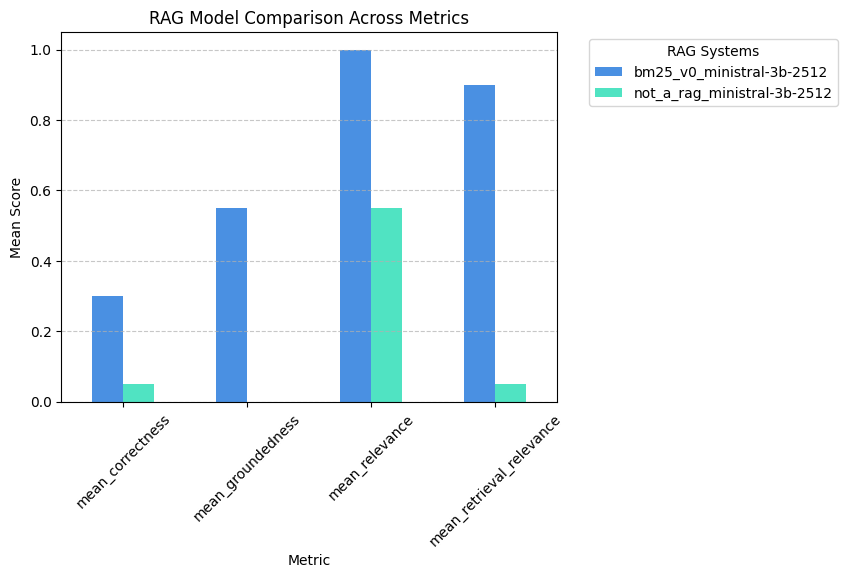

In [38]:
# Initialize benchmark
benchmark = Benchmark()

# Add evaluation results from different models
benchmark.add_results(bm25_v0_df)
benchmark.add_results(mistral_base_df)

# Compute summary statistics
summary_df = benchmark.compute_summary()
display(summary_df)  # Show the summary table

# Generate comparison plot
benchmark.plot_comparison()

## 📚 **Data Ingestion: Experimenting with Different Chunking Strategies**

So far, we have ingested our text using **a simple recursive character splitter** with specific `chunk_size` and `chunk_overlap` parameters.  
However, the way we **split documents into chunks** can significantly impact retrieval quality.

In this section, we will experiment with **different chunking strategies** and assess their impact on RAG performance.

<div class='alert alert-info'>

**Exercise 1:**

1️⃣ Modify the `chunk_size` to **128** and `chunk_overlap` to **16** in our **RecursiveCharacterTextSplitter**.

2️⃣ Create a new **BM25V1RAG** model that uses the updated chunked documents.

3️⃣ Compare its performance to `BM25V0RAG`.  
</div>

In [39]:
# Define a new chunking strategy with smaller chunk size
text_splitter_v1 = ...

# Apply the splitter
docs_v1 = ...

In [40]:
class BM25V1RAG(RAGInterface):
    """
    BM25-based RAG using an updated chunking strategy.
    """

    def __init__(self, generation_model: Union[ChatHuggingFace, ChatMistralAI]):
        # Initialize sparse embeddings
        sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

        # Create the knowledge database with updated chunks
        knowledge_db = ...

        # Initialize RAG Interface
        model_name = get_model_name(generation_model)
        name = f"bm25_v1_{model_name}"
        super().__init__(name=name, knowledge_db=knowledge_db)
        self.llm = generation_model
        self.retriever = self.knowledge_db.as_retriever(
            search_type="similarity", search_kwargs={"k": 5}  # Retrieve top-5 most relevant contexts
        )
        self.gen_prompt = gen_prompt_v0  # Use the structured prompt

    def retrieve(self, query: str) -> List[Document]:
        """
        Retrieves relevant documents using BM25 sparse retrieval.

        Args:
            query (str): The user query.

        Returns:
            List[Document]: The most relevant document chunks.
        """
        retrieved_contexts = self.retriever.invoke(query)
        return retrieved_contexts

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        """
        Generates a response using the retrieved contexts.

        Args:
            query (str): The user query.
            retrieved_contexts (List[Document]): Retrieved document chunks.

        Returns:
            str: The generated answer.
        """
        # Format retrieved contexts into a single string
        format_retrieved_contexts = "\n".join([rc.page_content for rc in retrieved_contexts])

        # Format the query with the retrieved contexts
        augmented_query = self.gen_prompt.format(
            query=query,
            retrieved_contexts=format_retrieved_contexts
        )

        # Generate the final response
        response = self.llm.invoke(augmented_query)
        return response


Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


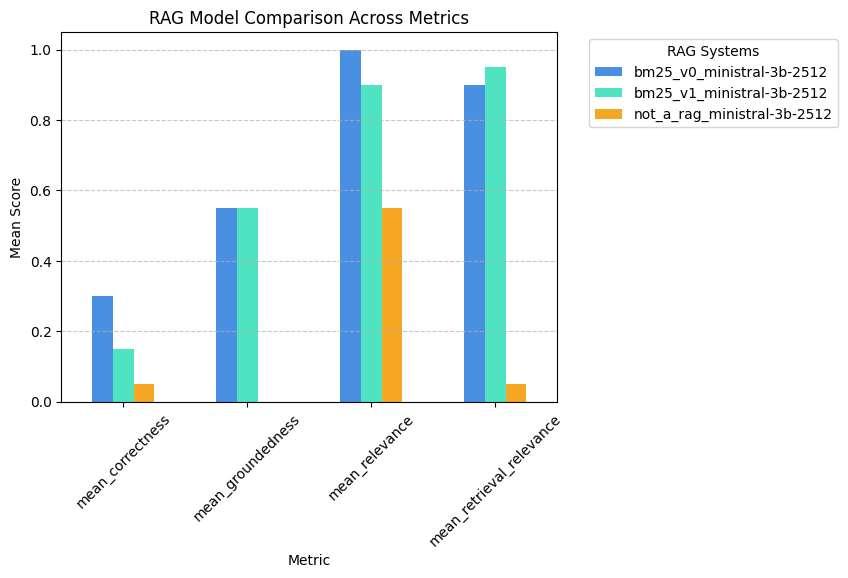

In [41]:
# Instantiate BM25V1RAG
bm25_v1 = ...

# Run the updated RAG model
bm25_v1_df = ...

# Evaluate performance
evaluate(bm25_v1_df)

# Add results to benchmark
benchmark.add_results(bm25_v1_df)

# Compare results visually
benchmark.plot_comparison()

**Semantic Chunking**

Semantic chunking is a technique used to divide text into meaningful segments based on their semantic content. Unlike traditional methods that split text by character or word count, semantic chunking aims to keep related ideas together and separate distinct concepts.

<div class="alert alert-info">

**Exercise 2:**

1️⃣ Read the [LangChain Semantic Chunking documentation](https://python.langchain.com/docs/how_to/semantic-chunker/).

2️⃣ Implement a **Semantic Chunker** using the current Embedding Model.

3️⃣ Build a **BM25V2RAG** model that uses the new chunking strategy.

4️⃣ Evaluate its performance and compare it to **BM25V1RAG** and **BM25V0RAG**.

</div>

In [42]:
from langchain_experimental.text_splitter import SemanticChunker

text_splitter_v2 = ...

docs_v2 = ...

In [43]:
class BM25V2RAG(RAGInterface):
    """
    BM25-based RAG using a semantic chunking strategy.
    """

    def __init__(self, generation_model: Union[ChatHuggingFace, ChatMistralAI]):
        # Initialize sparse embeddings
        sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

        # Create the knowledge database with updated chunks
        knowledge_db = ...

        # Initialize RAG Interface
        model_name = get_model_name(generation_model)
        name = f"bm25_v2_{model_name}"
        super().__init__(name=name, knowledge_db=knowledge_db)
        self.llm = generation_model
        self.retriever = self.knowledge_db.as_retriever(
            search_type="similarity", search_kwargs={"k": 5}  # Retrieve top-5 most relevant contexts
        )
        self.gen_prompt = gen_prompt_v0  # Use the structured prompt

    def retrieve(self, query: str) -> List[Document]:
        """
        Retrieves relevant documents using BM25 sparse retrieval.

        Args:
            query (str): The user query.

        Returns:
            List[Document]: The most relevant document chunks.
        """
        retrieved_contexts = self.retriever.invoke(query)
        return retrieved_contexts

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        """
        Generates a response using the retrieved contexts.

        Args:
            query (str): The user query.
            retrieved_contexts (List[Document]): Retrieved document chunks.

        Returns:
            str: The generated answer.
        """
        # Format retrieved contexts into a single string
        format_retrieved_contexts = "\n".join([rc.page_content for rc in retrieved_contexts])

        # Format the query with the retrieved contexts
        augmented_query = self.gen_prompt.format(
            query=query,
            retrieved_contexts=format_retrieved_contexts
        )

        # Generate the final response
        response = self.llm.invoke(augmented_query)
        return response


Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


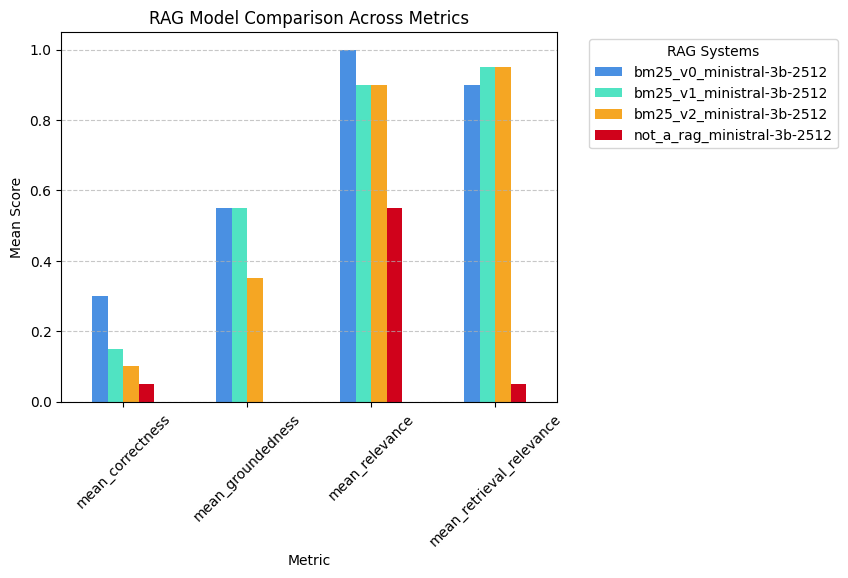

In [44]:
# Instantiate BM25V2RAG
bm25_v2 = BM25V2RAG(generation_model=generation_llm)

# Run the updated RAG model
bm25_v2_df = run_rag_on_df(rag=bm25_v2, eval_df=eval_df)

# Evaluate performance
evaluate(bm25_v2_df)

# Add results to benchmark
benchmark.add_results(bm25_v2_df)

# Compare results visually
benchmark.plot_comparison()

## 🔎 Dense Retrieval: Leveraging Embeddings for Semantic Search

So far, we have explored **sparse retrieval** (BM25), which relies on **exact keyword matching**. However, sparse retrieval has **limitations**:
- It struggles with **synonyms and rewordings**.
- It fails to capture **semantic similarity** beyond lexical overlap.

To overcome this, we use **Dense Retrieval**, where documents and queries are represented as **dense vector embeddings** in a high-dimensional space.

### 🚀 **How Does Dense Retrieval Work?**
1️⃣ **Each document is embedded** using a neural network (e.g., `HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")`).  
2️⃣ **The query is embedded** using the same model.  
3️⃣ **Vector similarity (e.g., cosine similarity)** is used to retrieve the most relevant documents.  


<div class="alert alert-info">

**Exercise 3:**

1️⃣ Read the [LangChain Qdrant Dense Retrieval documentation](https://python.langchain.com/docs/integrations/vectorstores/qdrant/#dense-vector-search).

2️⃣ Implement three versions of **Dense RAG**:  
   - `DENSEV0RAG`: Uses **RecursiveCharacterTextSplitter (docs_v0)**.  
   - `DENSEV1RAG`: Uses **RecursiveCharacterTextSplitter with different chunking params (docs_v1)**.  
   - `DENSEV2RAG`: Uses **Semantic Splitting (docs_v2)**.

3️⃣ Compare Dense Retrieval to BM25-based retrieval using the **qualitative dataset**.  
   - Do you notice a **difference in retrieved contexts**?  
   - Which method seems to **better capture semantic meaning**?

4️⃣ Add them to the benchmark
</div>

In [45]:
class DENSEV0RAG(RAGInterface):
    """
    Dense Retrieval RAG using embeddings for similarity search.
    Uses RecursiveCharacterTextSplitter (docs_v0) as the ingestion strategy.
    """

    def __init__(self, generation_model: Union[ChatHuggingFace, ChatMistralAI]):
        # Create a dense retrieval knowledge base using embeddings
        knowledge_db = ...

        # Initialize RAG Interface
        ...

    def retrieve(self, query: str) -> List[Document]:
        return self.retriever.invoke(query)

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        formatted_contexts = "\n".join([rc.page_content for rc in retrieved_contexts])
        augmented_query = self.gen_prompt.format(query=query, retrieved_contexts=formatted_contexts)
        return self.llm.invoke(augmented_query)

In [46]:
# Instantiate the Dense RAG model (V0)
...

# Run Dense Retrieval on the evaluation dataset
...

# Evaluate performance
...

# Add results to benchmark
...

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


In [47]:
class DENSEV1RAG(RAGInterface):
    """
    Dense Retrieval RAG using smaller chunk size and overlap.
    Uses RecursiveCharacterTextSplitter (docs_v1) as the ingestion strategy.
    """

    def __init__(self, generation_model: Union[ChatHuggingFace, ChatMistralAI]):
        # Create a dense retrieval knowledge base using embeddings
        knowledge_db = ...

        # Initialize RAG Interface
        ...

    def retrieve(self, query: str) -> List[Document]:
        ...

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        ...

In [48]:
# Instantiate the Dense RAG model (V1)
dense_v1 = DENSEV1RAG(generation_model=generation_llm)

# Run Dense Retrieval on the evaluation dataset
dense_v1_df = run_rag_on_df(rag=dense_v1, eval_df=eval_df)

# Evaluate performance
evaluate(dense_v1_df)

# Add results to benchmark
benchmark.add_results(dense_v1_df)

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


In [50]:
class DENSEV2RAG(RAGInterface):
    """
    Dense Retrieval RAG using Semantic Chunking.
    Uses SemanticChunker (docs_v2) as the ingestion strategy.
    """

    def __init__(self, generation_model: Union[ChatHuggingFace, ChatMistralAI]):
        ...

    def retrieve(self, query: str) -> List[Document]:
        ...

    def generate(self, query: str, retrieved_contexts: List[Document]) -> str:
        ...

In [51]:
...

# Add results to benchmark
...

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


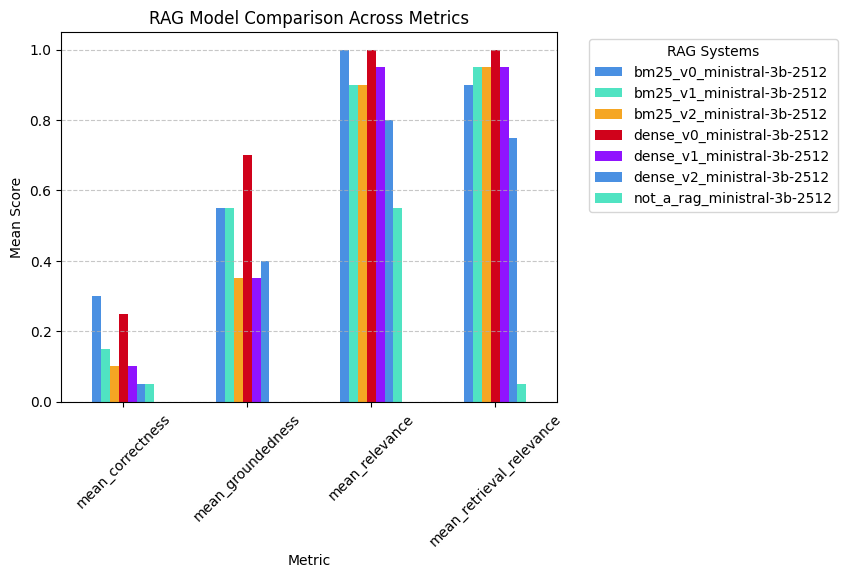

In [52]:
# Compare Dense Retrieval to previous methods
benchmark.plot_comparison()

## 🔄 Hybrid Retrieval: Combining the Best of Both Worlds

In the previous sections, we explored:
- **Sparse Retrieval (BM25)** → Effective for **exact keyword matching**.
- **Dense Retrieval (Embeddings)** → Effective for **semantic similarity**.

While both approaches have their **strengths**, they also have **limitations**.  
Hybrid Retrieval **combines sparse and dense retrieval**, ensuring better coverage and accuracy.

#### 🎯 **How Does Hybrid Retrieval Work?**

- **Both BM25 and embedding-based retrieval are performed** on the query.  
- **Results from both methods are combined** using a **fusion algorithm**.  
- The best-matching documents are **ranked and returned** for generation.

#### 🚀 **Fusion Algorithms: How Do We Combine Results?**
There are multiple ways to **merge results from sparse and dense retrieval**.  
We will experiment with two fusion techniques:

- **Reciprocal Rank Fusion (RRF)**
- **Distribution-Based Score Fusion (DBSF)**


<div class="alert alert-info">

**Exercise 4:**

1️⃣ Read the [LangChain Qdrant Hybrid Retrieval documentation](https://python.langchain.com/docs/integrations/vectorstores/qdrant).

2️⃣ Define `rrf` and `dbsf` using qdrant_client.models package, [Qdrant Client Code](https://github.com/qdrant/qdrant-client/blob/master/qdrant_client/http/models/models.py).

3️⃣ Using the Langchain Qdrant `RetrievalMode.HYBRID` and by checking the [API Reference](https://python.langchain.com/api_reference/_modules/langchain_qdrant/qdrant.html), implement two versions of **Hybrid RAG**:
   - `HYBRIDV0RAG` → Uses **RRF (Reciprocal Rank Fusion)**.  
   - `HYBRIDV1RAG` → Uses **DBSF (Distance-Based Score Fusion)**.  

(You can choose the ingestion pipeline that you think it's best)


4️⃣ Compare Hybrid Retrieval to **BM25 and Dense Retrieval**:
   - Does Hybrid Retrieval **outperform** the individual methods?  
   - How do the **fusion algorithms affect retrieval results**?

</div>

In [53]:
# Define Fusion Algorithms
from qdrant_client import models

rrf = ...
dbsf = ...

In [54]:
class HYBRIDV0RAG(RAGInterface):
    """
    Hybrid RAG using Reciprocal Rank Fusion (RRF).
    Combines Sparse (BM25) and Dense (Embeddings) retrieval.
    """
    ...


In [56]:
# Instantiate Hybrid RAG model (RRF)
...

# Run Hybrid Retrieval on the evaluation dataset
...

# Evaluate performance
...

# Add results to benchmark
...

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


In [57]:
class HYBRIDV1RAG(RAGInterface):
    """
    Hybrid RAG using Distribution-Based Score Fusion (DBSF).
    Combines Sparse (BM25) and Dense (Embeddings) retrieval.
    """
    ...


In [58]:

# Instantiate Hybrid RAG model (DBSF)
...

# Run Hybrid Retrieval on the evaluation dataset
...

# Evaluate performance
...

# Add results to benchmark
...

Evaluation start:


Evaluating correctness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating groundedness:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating retrieval_relevance:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluation finished


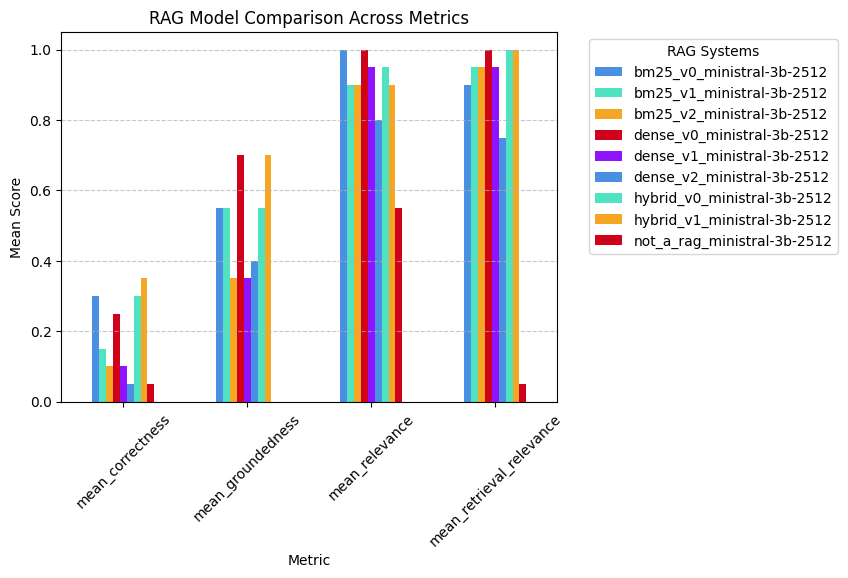

In [59]:
# Compare Hybrid Retrieval to previous methods
benchmark.plot_comparison()

## 🔭 Going Further

<div class="alert alert-info">

**Optional Exercise**: Improving the Evaluation Dataset

**Difficulty**: Hard

**Note**: This exercise requires a non-trivial amount of work. It is not strictly a RAG implementation problem, but it is essential for producing meaningful RAG evaluations.

So far, we have benchmarked our RAG systems using an automatically generated evaluation dataset. If you inspect this dataset carefully, you will notice that many entries are fragile or poorly grounded (e.g., ambiguous questions, weakly supported answers, or questions that implicitly rely on the context being shown).

This has an important consequence:
the quality of the evaluation dataset directly biases the benchmark results, making model comparisons unreliable or even misleading.

Although this dataset was intentionally kept simple for demonstration purposes, its limitations significantly affect the validity of the analysis.

**Your task**

Design and implement a method to generate a higher-quality evaluation dataset for RAG systems.


<div class="alert alert-info">

**Exercise 5: Enhancing Ingestion and Retrieval with Metadata**

In this exercise, you will define a **new ingestion pipeline** that enriches documents with **structured metadata**. This will allow for **more context-aware retrieval**, improving the accuracy and coherence of retrieved information.

### **📌 Ingestion Pipeline**

You will modify the **text chunking strategy** to improve retrieval quality. Specifically:
- **Chunk the text every time the speaker changes** (except in the **intro** and **characters presentation**).
- **Replace abbreviated speaker names** with their **full names** (e.g., `HARP.` → `HARPAGON`).

Each chunk should include **the following metadata**:
- **Type of text** → One of:
  - `"intro"` → General introduction.
  - `"characters_presentation"` → List of characters.
  - `"play"` → Spoken dialogue.
- **If the text is `"play"`**, also store:
  - **The section** it belongs to (**Act #, Scene #**).
  - **A list of characters** present in that section.
  - **The chunk ID within the section** (i.e., speech order in the scene).

**💡 Tip: Using Metadata Inheritance**

When chunking the document, **LangChain allows metadata inheritance**:
- **You can attach metadata to an entire document before chunking**.
- **Each resulting chunk will automatically inherit the metadata** unless explicitly overwritten.

**How can this help?**
- Instead of **manually adding act, scene, and characters metadata** to every chunk, **attach it at the section level** before splitting.
- This ensures **consistency** and **reduces redundant operations**.

### **🔍 Retrieval Behavior**

After performing a Hybrid Search, apply the following post-processing rules:
-When a chunk of type "play" is retrieved, also retrieve:
    - The previous chunk, if available (unless it is the first in its section).
    - The next chunk, if available (unless it is the last in its section).
- Merge adjacent retrieved chunks within the same section:
    - If multiple chunks belong to the same scene and are adjacent, concatenate them into one block.
    - Assign the highest individual retrieval score to the merged block.

### **📑 Context Formatting**

When formatting retrieved contexts for generation, use the following structure:
```shell
Context #1:
Act <Act #>, Scene <Scene #> - Characters involved: [list of characters]
[retrieved speech]
----
Context #2:
Intro
[retrieved part of the introduction]
----
Context #3:
Act <Act #>, Scene <Scene #> - Characters involved: [list of characters]
[retrieved speech]
```

<div class="alert alert-info">

**Exercise 6: Improving Generation with a Larger Model**

### **🚀 Context**
Until now, we have been using `"ministral-3b-2512"` as our generation model.  
Now, we will **upgrade** to `"ministral-14b-2512"` (12B), which has:

### **🎯 Your Task**
- **Improve the generation prompt** to take advantage of `"ministral-14b-2512"`.  
- **Optimize system instructions** to **guide the model better**.  
- **Be careful about prompt length**:
   - The prompt **+ retrieved context** must **fit inside the model's context window**.
   - Some queries will **retrieve multiple large contexts**, so **avoid an excessively long system prompt**.

### **💡 Things to Consider**
- What **additional instructions** could improve the answer?  
- Should the **formatting of retrieved contexts** change for better coherence?  
- How can we make the **prompt more structured** without wasting tokens?
- You can get inspiration for [Prompt here](https://smith.langchain.com/hub/)

**🔥 Challenge:**  
Can you compare **different prompt versions** and analyze their impact on generated answers?

</div>


<div class="alert alert-info">

**Exercise 7: Query Routing Using Metadata Filters**

### **🚀 Context**
Right now, our retriever **searches all sections** every time.  
However, if a **query is about a specific character or scene**, we can **filter retrieval** to improve efficiency and accuracy.

### **🎯 Your Task**
Modify the retriever to **detect query intent** and **apply metadata filters** before retrieval.

- **Step 1:** **Determine the Query Type**  
   - Is the user asking about a **specific character**?  
   - Does the query mention a **specific act or scene**?  

- **Step 2:** **Apply Metadata Filters**  
   - If the query **mentions a character**, **retrieve only sections where that character appears**.  
   - If the query **mentions an act/scene**, **restrict retrieval to that section**.  

### **💡 Things to Consider**
- **How will you detect named entities (characters, scenes)?**  
- **How can filters be applied efficiently?** (Qdrant vector stores have some built-in functionnalities)  
- **What happens if a query contains multiple filtering criteria?** (e.g., "What does Harpagon say in Act I?")  

**🔥 Challenge:**  
- Can you **combine filtering with Hybrid Retrieval** to **maintain accuracy** while reducing search space?

</div>
